## K-Means

### Este proyeto tiene como objetivo clasificar casas según su la región en la que se encuentren y del ingreso medio.
---

#### 0. Importación de librerías y dataset

> Note: The 'utils.py' file contains specific functions according to the standards of Exploratory Data Analysis (EDA) and Descriptive Data Analysis (DDA). The functions with the prefix 'eda' are described in the 'utils.py' doc

In [ ]:
# Statistic, dataframe and visualization libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
from mpl_toolkits.mplot3d import Axes3D

# ML model related libraries
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import plotly.express as px

# ML model wrapper library
from pickle import dump

# Custom functions
import utils as eda

# Dataset
URL = "https://raw.githubusercontent.com/4GeeksAcademy/k-means-project-tutorial/main/housing.csv"
df = pd.read_csv(URL)

df.head(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.02381,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.97188,2401.0,2.109842,37.86,-122.22,3.585


---

### 1.0 análisis descriptivo del dataset

> Vista rápida del contenido y características del dataset.

#### 1.1 Información general del dataset

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


> El dataset contiene lo siguiente:

> 20640 registros estructurados en 9 columnas.

> No posee celdas nulas

> Todos los registros son del tipo flotante

### 1.2 Tamaño y estructura

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


####  En este caso solo nos interesan las columnas Latitude, Longitude y MedInc. Latitud y Longitud no presentan Outliers visiblemente, MedInc sí los presenta y deberán ser inspeccionados y procesados a detalle posteriormente.

#### 1.3 Reestructuración de Dataset

In [4]:
columnas_a_trabajar = ['Latitude', 'Longitude', 'MedInc']
df_cluster = df[columnas_a_trabajar].copy()
df_cluster.head(2)  

,Latitude,Longitude,MedInc
0,37.88,-122.23,8.3252
1,37.86,-122.22,8.3014


In [5]:
df_cluster.describe().T

,count,mean,std,min,25%,50%,75%,max
Latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
Longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
MedInc,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001


### 1.3 Registros duplicados

In [6]:
df_cluster.duplicated().sum()

np.int64(5)

In [18]:
duplicados = df_cluster.duplicated()
df_cluster[duplicados]

,Latitude,Longitude,MedInc
4571,34.07,-118.27,2.3438
4606,34.07,-118.33,15.0001
8852,34.08,-118.42,15.0001
8854,34.07,-118.41,15.0001
16331,38.02,-121.33,4.3008


> El dataset no presenta duplicados en sus registros. Presenta coincidencias parciales únicamente, por lo tanto se descarta eliminaciónd e duplicados.

### 1.4 Valores "0"

In [8]:
print((df_cluster == 0).sum())

Latitude     0
Longitude    0
MedInc       0
dtype: int64


> Dataset no presenta valores 0

### 1.5 Visualización

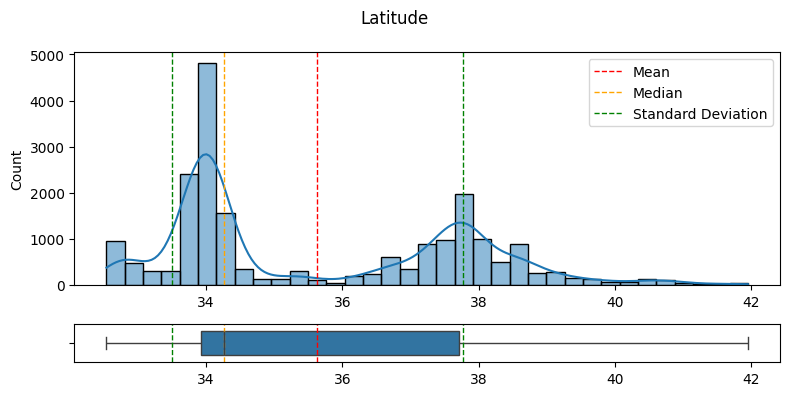

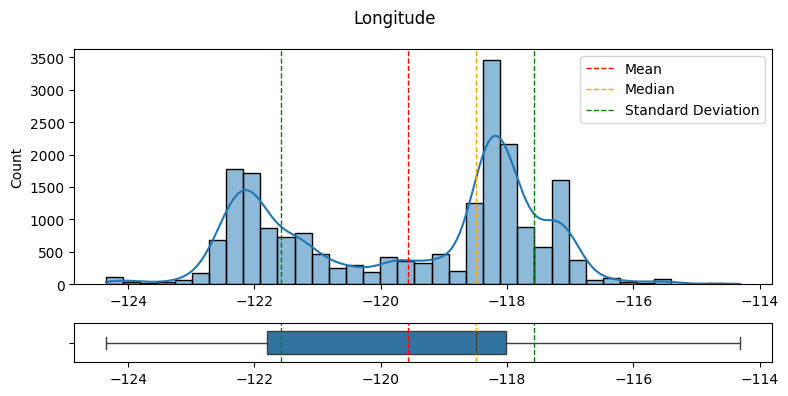

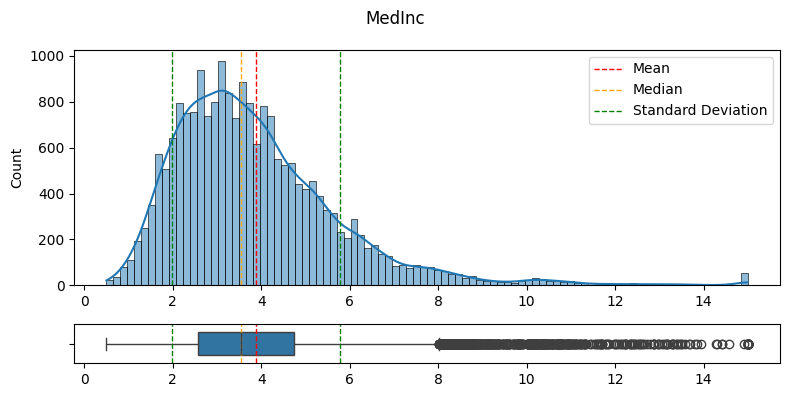

In [9]:
eda.plot_numerical_data(df_cluster)

In [10]:
fig_2d = px.scatter(df,
                    x='Longitude',
                    y='Latitude',
                    color='MedInc',
                    title='Mapa 2D: Ingreso Medio por Ubicación Geográfica',
                    labels={'Longitude': 'Longitud', 'Latitude': 'Latitud', 'MedInc': 'Ingreso Medio'},
                    color_continuous_scale='Viridis')

# Invertir eje X para reflejar geografía de California correctamente
fig_2d.update_layout(yaxis_title="Latitud", xaxis_title="Longitud")
fig_2d.update_yaxes(scaleanchor="x", scaleratio=1)


In [19]:

# Guardar como archivo HTML
html_path_2d = "../data/graficos/mapa_2d_ingreso.html"
fig_2d.write_html(html_path_2d)

html_path_2d

'../data/graficos/mapa_2d_ingreso.html'

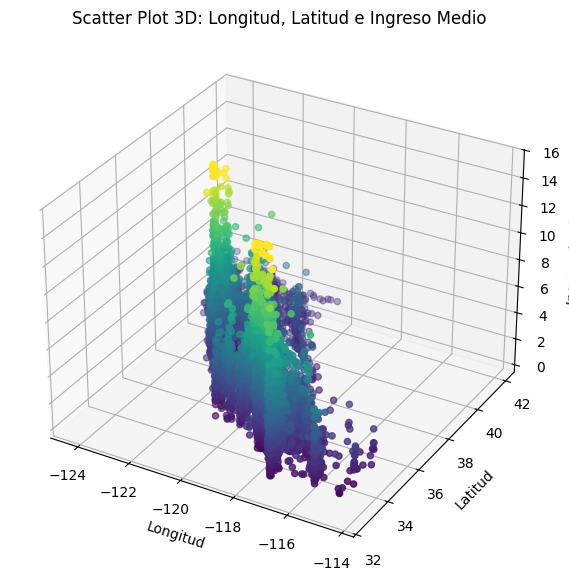

In [ ]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['Longitude'], df['Latitude'], df['MedInc'], c=df['MedInc'], cmap='viridis')

ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_zlabel('Ingreso Medio')
ax.set_title('Scatter Plot 3D: Longitud, Latitud e Ingreso Medio')

plt.show()

### import plotly.express as px
fig = px.scatter_3d(df,
                    x="petal width (cm)",
                    y="petal length (cm)",
                    z="sepal width (cm)",
                    color="specie",
                    width=1000,
                    height=500,
                    size=df["petal length (cm)"].abs(),
                    color_discrete_sequence=["#E58139", "#39E581", "#8139E5"])
camera = dict(up=dict(x=1, y=3.5, z=0),
              eye=dict(x=2, y=0, z=0))

fig.update_layout(scene_camera=cam

EDA